# Import Libraries

In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV,train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)


## Load Dataset

In [27]:
df = pd.read_csv("clean_data.csv")

In [28]:
df.head(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_log,Hour
0,-1.370413,1.095589,-0.668018,-0.024219,1.675652,3.823629,-0.634559,1.836666,-0.485368,-0.547920,...,-0.609795,0.027077,0.986022,0.079739,-0.463951,0.063528,0.006793,0,0.313613,-0.866491
1,1.805238,0.961264,-1.717212,4.094625,0.938666,-0.227785,0.152911,0.066753,-1.073784,0.334537,...,-0.450959,0.098530,-0.662272,-0.150154,-0.098852,-0.000030,0.017622,0,0.307105,-0.354251
2,-1.789123,0.941366,1.432897,-1.318458,-0.450124,-1.290731,0.933642,-0.306360,0.917978,0.722699,...,-0.202022,-0.017159,0.740137,-0.183085,0.692176,0.488185,0.418299,0,0.671760,1.353215
3,-0.711379,-1.431688,0.630874,-2.551985,0.509280,-0.565154,0.258866,-0.289951,-2.680067,1.154872,...,-1.064836,0.435373,-0.932473,-0.459677,-0.759301,-0.094306,-0.053401,0,1.110565,-0.354251
4,1.303287,1.023966,-3.187599,0.468391,3.353988,2.431416,0.184510,0.622721,-0.556254,-1.485591,...,-0.823366,-0.241908,0.674554,1.012236,-0.278656,0.041260,0.089912,0,-1.490648,-0.524998


## Feature Selection & Targret Col

In [29]:
X=df.drop("Class",axis=1)
y=df["Class"]

## Train Test Split

In [30]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


## Calculate scale_pos_weight

In [31]:
non_fraud = (y_train == 0).sum()

fraud = (y_train == 1).sum()

ratio = non_fraud / fraud

print("Scale Pos Weight =", ratio)

Scale Pos Weight = 578.7101449275362


## Baseline XGBoost

In [32]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [33]:
y_pred = xgb.predict(X_test)

y_prob = xgb.predict_proba(X_test)[:,1]

## Evaluation

In [34]:
print("Accuracy :",accuracy_score(y_test,y_pred))

print("Precision :", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

print("PR-AUC :", average_precision_score(y_test, y_prob))

Accuracy : 0.9997
Precision : 1.0
Recall : 0.8235294117647058
F1 Score : 0.9032258064516129
PR-AUC : 0.896845694799659


## Precision-Recall Curve

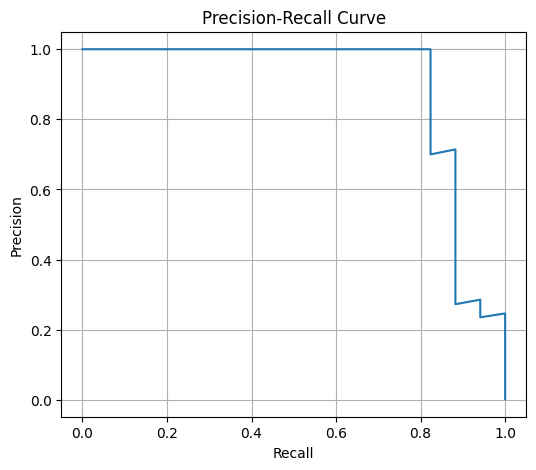

In [35]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

## Hyperparameter Tuning

In [36]:
params = {

    "n_estimators":[100,200,300],
    "max_depth":[3,4,5,6],
    "learning_rate":[0.01,0.05,0.1],
    "subsample":[0.6,0.8,1.0],
    "colsample_bytree":[0.6,0.8,1.0]
}

In [37]:
random_search = RandomizedSearchCV(

    estimator=XGBClassifier(
        scale_pos_weight=ratio,
        random_state=42,
        eval_metric="logloss"
    ),

    param_distributions=params,
    n_iter=15,
    cv=3,
    scoring="average_precision",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that

## Best Parameters

In [38]:
print("Best Parameters")
print(random_search.best_params_)
print()

print("Best CV PR-AUC")
print(random_search.best_score_)

Best Parameters
{'subsample': 0.6, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best CV PR-AUC
0.8042548852105508


## Best Model

In [39]:
best_xgb = random_search.best_estimator_

## Evaluate Tuned Model

In [40]:
y_pred_best = best_xgb.predict(X_test)

y_prob_best = best_xgb.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test,y_pred_best))
print("Precision :", precision_score(y_test,y_pred_best))

print("Recall :", recall_score(y_test,y_pred_best))

print("F1 Score :", f1_score(y_test,y_pred_best))
print("PR-AUC :", average_precision_score(y_test,y_prob_best))

Accuracy: 0.9996
Precision : 0.9333333333333333
Recall : 0.8235294117647058
F1 Score : 0.875
PR-AUC : 0.9416510133465151


## Compare Before and After Tuning

In [41]:
baseline = average_precision_score(y_test, y_prob)

tuned = average_precision_score(y_test, y_prob_best)

print("Baseline PR-AUC :", baseline)
print("Tuned PR-AUC :", tuned)

Baseline PR-AUC : 0.896845694799659
Tuned PR-AUC : 0.9416510133465151


## Precision-Recall Curve with Default Threshold (0.5)

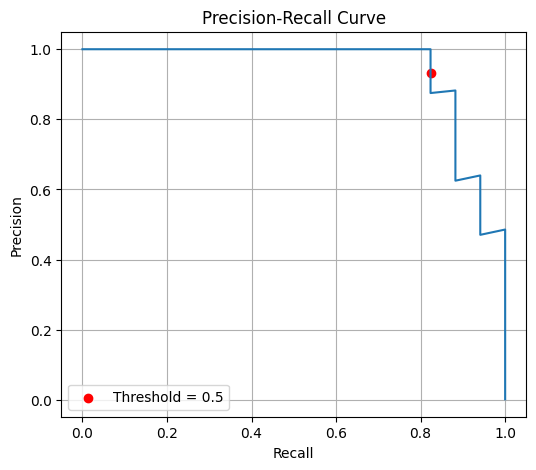

In [42]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_best)

plt.figure(figsize=(6,5))

plt.plot(recall, precision)

index = np.argmin(np.abs(thresholds-0.5))

plt.scatter(recall[index], precision[index], color="red", label="Threshold = 0.5")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

## Best F1 Threshold

In [43]:
f1_scores = 2*(precision[:-1]*recall[:-1])/(precision[:-1]+recall[:-1]+1e-10)

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

print("Best Threshold :", best_threshold)
print("Best F1 :", f1_scores[best_index])

Best Threshold : 0.8439439
Best F1 : 0.9032258064020812


## Threshold with Recall ≥ 0.90

In [44]:
valid = np.where(recall[:-1] >= 0.90)[0]

best_recall = valid[np.argmax(precision[:-1][valid])]

threshold90 = thresholds[best_recall]

print("Threshold :", threshold90)
print("Precision :", precision[best_recall])
print("Recall :", recall[best_recall])

Threshold : 0.01693524
Precision : 0.64
Recall : 0.9411764705882353


## Evaluate at Best F1 Threshold

In [45]:
pred_best = (y_prob_best >= best_threshold).astype(int)

print("Precision :", precision_score(y_test,pred_best))
print("Recall :", recall_score(y_test,pred_best))
print("F1 Score :", f1_score(y_test,pred_best))
print("PR-AUC :", average_precision_score(y_test,y_prob_best))

Precision : 1.0
Recall : 0.8235294117647058
F1 Score : 0.9032258064516129
PR-AUC : 0.9416510133465151


## Evaluate at Recall ≥ 0.90 Threshold

In [46]:
pred90 = (y_prob_best >= threshold90).astype(int)

print("Precision :", precision_score(y_test,pred90))
print("Recall :", recall_score(y_test,pred90))
print("F1 Score :", f1_score(y_test,pred90))
print("PR-AUC :", average_precision_score(y_test,y_prob_best))

Precision : 0.64
Recall : 0.9411764705882353
F1 Score : 0.7619047619047619
PR-AUC : 0.9416510133465151


## Save a Trained Model

In [47]:
import joblib

joblib.dump(best_xgb, "frauddetection_model.pkl")

['frauddetection_model.pkl']

In [48]:
model = joblib.load("frauddetection_model.pkl")

# Conclusion

This project successfully developed an XGBoost model for detecting fraudulent credit card transactions. The model was trained on the original training dataset using the scale_pos_weight parameter to address the class imbalance between legitimate and fraudulent transactions. This enabled the model to focus more effectively on the minority (fraud) class.

The performance of the baseline XGBoost model was evaluated using Precision, Recall, F1-Score, and PR-AUC, which are appropriate metrics for highly imbalanced datasets. To further improve performance, RandomizedSearchCV was used for hyperparameter tuning. The tuned model achieved better predictive performance and an improved PR-AUC compared to the baseline model.

Threshold optimization was then performed using the Precision-Recall curve. Instead of using the default prediction threshold of 0.5, the model was evaluated at the threshold that maximized the F1-Score and at another threshold that achieved Recall ≥ 0.90 with the highest possible precision. This allowed the model to detect more fraudulent transactions while controlling the number of false positives according to business requirements.

| Metric    | Before Tuning         | After Tuning                |
| --------- | --------------------- | --------------------------- |
| Accuracy  |   o.99     |     0.99         |
| Precision |   0.99     |     0.64         |
| Recall    |   0.82     |     0.94         |
| F1-Score  |   0.90     |     0.76         |
| PR-AUC    |   0.89     |     0.94         |


Overall, the XGBoost model demonstrated excellent performance for credit card fraud detection. Its ability to handle imbalanced data, learn complex relationships, and improve through hyperparameter tuning and threshold optimization makes it a highly effective and reliable solution for real-world fraud detection systems.